
# Real Gingles Preprocessing Notebook

This notebook implements the following work only:

- **Preprocessing-7: Gingles 2/3 precinct analysis**
- **Preprocessing-8: Gingles 2/3 non-linear regression analysis**

It produces database-ready JSON payloads that are intended to replace the current synthetic Gingles records in:

- `gingles_results`
- `gingles_tables`

This notebook does **not** write directly to MongoDB. It produces canonical JSON artifacts that can later be inserted for:

- `OR`, `latino`, `2024_pres`
- `SC`, `black`, `2024_pres`

Locked minority-effective population definitions:

- **Oregon** uses `hispanic`
- **South Carolina** uses `black`



## Imports and Configuration

This section defines shared imports, project paths, and state-specific configuration. The notebook writes final JSON under `preprocessing/output/` and renders debug charts inline only.


In [1]:

from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from jsonschema import validate as jsonschema_validate
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)


def resolve_project_root() -> Path:
    """Resolve the repository root whether the notebook is run from the repo or preprocessing/."""
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'schemas').exists() and (candidate / 'preprocessing').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not resolve the project root from the current working directory.')


PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / 'preprocessing' / 'output'
SCATTER_SCHEMA_PATH = PROJECT_ROOT / 'schemas' / 'v1' / 'gingles-scatter.schema.json'

STATE_CONFIGS: dict[str, dict[str, Any]] = {
    'OR': {
        'state_code': 'OR',
        'selected_group_label': 'Latino',
        'group_key': 'latino',
        'minority_column': 'hispanic',
        'input_csv': Path('/Users/sahilparikh/Downloads/or_combined.csv'),
        'scatter_output': OUTPUT_DIR / 'OR_2024_latino_gingles_scatter.json',
        'table_output': OUTPUT_DIR / 'OR_2024_latino_gingles_table.json',
        'total_districts': 6,
        'election_id': '2024_pres',
        'election_label': '2024 Presidential',
        'plot_target_precincts': 300,
    },
    'SC': {
        'state_code': 'SC',
        'selected_group_label': 'Black',
        'group_key': 'black',
        'minority_column': 'black',
        'input_csv': Path('/Users/sahilparikh/Downloads/sc_combined.csv'),
        'scatter_output': OUTPUT_DIR / 'SC_2024_black_gingles_scatter.json',
        'table_output': OUTPUT_DIR / 'SC_2024_black_gingles_table.json',
        'total_districts': 7,
        'election_id': '2024_pres',
        'election_label': '2024 Presidential',
        'plot_target_precincts': 400,
    },
}

REQUIRED_COLUMNS = [
    'precinct_id',
    'total',
    'white',
    'black',
    'asian',
    'hispanic',
    'other',
    'democratic_votes',
    'republican_votes',
    'total_votes',
]

NUMERIC_COLUMNS = [
    'total',
    'white',
    'black',
    'asian',
    'hispanic',
    'other',
    'democratic_votes',
    'republican_votes',
    'total_votes',
]



## Input Loading and Shared Validation Helpers

These helpers load the state CSVs, normalize their fields, and validate the assumptions needed by both preprocessing stages.


In [2]:

def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize names and types up front so the rest of the pipeline can stay state-agnostic."""
    normalized = df.copy()
    normalized.columns = [str(column).strip().lower() for column in normalized.columns]

    if 'precinct_id' in normalized.columns:
        normalized['precinct_id'] = normalized['precinct_id'].astype(str).str.strip()

    for column in NUMERIC_COLUMNS:
        if column in normalized.columns:
            normalized[column] = pd.to_numeric(normalized[column], errors='coerce')

    for column in ['district', 'representative', 'party', 'incumbent_race', 'margin']:
        if column in normalized.columns:
            normalized[column] = normalized[column].astype(str).str.strip()

    return normalized


def load_state_csv(csv_path: str | Path) -> pd.DataFrame:
    """Load a single state CSV and apply consistent normalization."""
    frame = pd.read_csv(csv_path)
    return normalize_dataframe(frame)


def validate_required_columns(df: pd.DataFrame, required_columns: list[str], label: str) -> None:
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f'{label} is missing required columns: {missing_columns}')


def validate_demographic_totals(df: pd.DataFrame, label: str) -> None:
    # Use strict equality here because downstream minority-share calculations assume internally consistent row totals.
    components = df[['white', 'black', 'asian', 'hispanic', 'other']].sum(axis=1)
    mismatched = df.loc[components != df['total'], ['precinct_id', 'total']]
    if not mismatched.empty:
        preview = mismatched.head(5).to_dict(orient='records')
        raise ValueError(f'{label} has rows where demographic totals do not match total: {preview}')


def validate_unique_precinct_ids(df: pd.DataFrame, label: str) -> None:
    duplicate_ids = df.loc[df['precinct_id'].duplicated(), 'precinct_id'].tolist()
    if duplicate_ids:
        preview = duplicate_ids[:5]
        raise ValueError(f'{label} contains duplicate precinct_id values: {preview}')


def validate_nonnegative_numeric_columns(df: pd.DataFrame, numeric_columns: list[str], label: str) -> None:
    for column in numeric_columns:
        negatives = df.loc[df[column] < 0, ['precinct_id', column]]
        if not negatives.empty:
            preview = negatives.head(5).to_dict(orient='records')
            raise ValueError(f'{label} contains negative values in {column}: {preview}')


def summarize_input_frame(df: pd.DataFrame, label: str) -> None:
    print(f'--- {label} input summary ---')
    print(f'Rows: {len(df):,}')
    print('Null counts:')
    print(df[REQUIRED_COLUMNS].isna().sum())
    print('Basic totals:')
    print(df[NUMERIC_COLUMNS].sum())
    display(df.head(3))


def validate_input_frame(df: pd.DataFrame, label: str) -> None:
    """Fail fast on source-shape issues before any analysis, fitting, or plotting begins."""
    validate_required_columns(df, REQUIRED_COLUMNS, label)
    validate_unique_precinct_ids(df, label)
    validate_nonnegative_numeric_columns(df, NUMERIC_COLUMNS, label)
    validate_demographic_totals(df, label)



## Preprocessing-7: Gingles 2/3 Precinct Analysis

This stage computes the precinct-level minority-effective population, minority-effective share, party vote shares, and winning party for each state.


In [3]:

def select_minority_population(df: pd.DataFrame, minority_column: str) -> pd.Series:
    """Select the configured minority-effective population column for the state."""
    return pd.to_numeric(df[minority_column], errors='coerce')


def compute_vote_shares(df: pd.DataFrame) -> pd.DataFrame:
    """Compute Democratic and Republican vote shares for each precinct."""
    computed = df.copy()
    computed['demVoteShare'] = computed['democratic_votes'] / computed['total_votes']
    computed['repVoteShare'] = computed['republican_votes'] / computed['total_votes']
    return computed


def compute_winning_party(df: pd.DataFrame) -> pd.Series:
    """Determine the precinct winner from raw two-party vote totals."""
    return np.where(df['democratic_votes'] > df['republican_votes'], 'DEM', 'REP')


def filter_invalid_precinct_rows(df: pd.DataFrame, minority_column: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Filter invalid precinct rows while keeping an audit trail of exclusions."""
    working = df.copy()
    working['minorityPopulation'] = select_minority_population(working, minority_column)

    # Labeling exclusion reasons keeps dropped rows inspectable later instead of silently disappearing.
    exclusion_conditions = {
        'missing_precinct_id': working['precinct_id'].isna() | (working['precinct_id'].astype(str).str.strip() == ''),
        'invalid_total_population': working['total'].isna() | (working['total'] <= 0),
        'invalid_minority_population': working['minorityPopulation'].isna() | (working['minorityPopulation'] < 0) | (working['minorityPopulation'] > working['total']),
        'invalid_total_votes': working['total_votes'].isna() | (working['total_votes'] <= 0),
        'invalid_vote_values': (
            working['democratic_votes'].isna()
            | working['republican_votes'].isna()
            | (working['democratic_votes'] < 0)
            | (working['republican_votes'] < 0)
        ),
    }

    exclusion_reason = pd.Series(index=working.index, dtype='object')
    for reason, condition in exclusion_conditions.items():
        exclusion_reason = exclusion_reason.mask(condition & exclusion_reason.isna(), reason)

    excluded_df = working.loc[exclusion_reason.notna()].copy()
    excluded_df['exclusion_reason'] = exclusion_reason.loc[excluded_df.index]

    valid_df = working.loc[exclusion_reason.isna()].copy()
    return valid_df, excluded_df


def build_precinct_analysis_frame(df: pd.DataFrame, state_cfg: dict[str, Any]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build the final precinct analysis frame for Preprocessing-7."""
    valid_df, excluded_df = filter_invalid_precinct_rows(df, state_cfg['minority_column'])
    valid_df = compute_vote_shares(valid_df)
    valid_df['winningParty'] = compute_winning_party(valid_df)
    valid_df['minorityShare'] = valid_df['minorityPopulation'] / valid_df['total']

    # Preserve derived analysis columns for fitting while shaping the same frame into frontend-friendly
    # camelCase fields that can be exported without a second transformation pass.
    valid_df['precinctId'] = valid_df['precinct_id']
    valid_df['precinctName'] = valid_df['precinct_id']
    valid_df['totalPopulation'] = valid_df['total'].round().astype(int)
    valid_df['democraticVotes'] = valid_df['democratic_votes'].round().astype(int)
    valid_df['republicanVotes'] = valid_df['republican_votes'].round().astype(int)
    valid_df['totalVotes'] = valid_df['total_votes'].round().astype(int)
    valid_df['minorityPopulation'] = valid_df['minorityPopulation'].round().astype(int)

    analysis_columns = [
        'precinctId',
        'precinctName',
        'totalPopulation',
        'minorityPopulation',
        'minorityShare',
        'democraticVotes',
        'republicanVotes',
        'totalVotes',
        'demVoteShare',
        'repVoteShare',
        'winningParty',
        'district',
        'representative',
        'party',
        'incumbent_race',
        'margin',
    ]
    available_columns = [column for column in analysis_columns if column in valid_df.columns]
    analysis_df = valid_df[available_columns].copy()
    return analysis_df, excluded_df


def validate_precinct_analysis_frame(df: pd.DataFrame, label: str) -> None:
    # This validates the downstream API payload contract, not just notebook-local sanity.
    if df.empty:
        raise ValueError(f'{label} produced an empty precinct analysis frame.')

    share_columns = ['minorityShare', 'demVoteShare', 'repVoteShare']
    for column in share_columns:
        if ((df[column] < 0) | (df[column] > 1)).any():
            raise ValueError(f'{label} contains out-of-bounds values in {column}.')

    if (df['minorityPopulation'] > df['totalPopulation']).any():
        raise ValueError(f'{label} has minorityPopulation values greater than totalPopulation.')

    if (df['democraticVotes'] > df['totalVotes']).any() or (df['republicanVotes'] > df['totalVotes']).any():
        raise ValueError(f'{label} has vote totals that exceed totalVotes.')


def sample_precincts_for_plotting(
    analysis_df: pd.DataFrame,
    target_precincts: int,
    n_bins: int = 40,
    random_seed: int = 42,
) -> pd.DataFrame:
    """Sample precincts by minority-share bins so sparse tails remain visible."""
    if len(analysis_df) <= target_precincts:
        sampled = analysis_df.copy()
        sampled['display_bin'] = pd.cut(sampled['minorityShare'], bins=np.linspace(0.0, 1.0, n_bins + 1), include_lowest=True)
        return sampled

    working = analysis_df.copy()
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    working['display_bin'] = pd.cut(working['minorityShare'], bins=bin_edges, include_lowest=True, duplicates='drop')
    grouped = working.groupby('display_bin', observed=True)
    bin_sizes = grouped.size().sort_index()
    non_empty_bins = bin_sizes[bin_sizes > 0]
    if non_empty_bins.empty:
        return working.sample(n=target_precincts, random_state=random_seed).copy()

    # Bin-aware sampling is preferred to simple random sampling because the rare high-share tails carry
    # much of the visual signal in a Gingles scatter plot.
    guaranteed = min(target_precincts, len(non_empty_bins))
    allocations = {bin_key: 1 for bin_key in non_empty_bins.index[:guaranteed]}
    remaining_slots = target_precincts - sum(allocations.values())
    total_in_non_empty = int(non_empty_bins.sum())

    if remaining_slots > 0:
        fractional_scores: list[tuple[Any, float]] = []
        for bin_key, bin_count in non_empty_bins.items():
            proportional = remaining_slots * (bin_count / total_in_non_empty)
            integer_add = int(np.floor(proportional))
            current = allocations.get(bin_key, 0)
            max_possible_add = max(0, int(bin_count) - current)
            applied_add = min(integer_add, max_possible_add)
            allocations[bin_key] = current + applied_add
            fractional_scores.append((bin_key, proportional - integer_add))

        remaining_after_floor = target_precincts - sum(allocations.values())
        if remaining_after_floor > 0:
            for bin_key, _ in sorted(fractional_scores, key=lambda item: item[1], reverse=True):
                if remaining_after_floor == 0:
                    break
                current = allocations.get(bin_key, 0)
                if current < int(non_empty_bins[bin_key]):
                    allocations[bin_key] = current + 1
                    remaining_after_floor -= 1

    sampled_frames = []
    for bin_key, bin_df in grouped:
        if bin_key not in allocations:
            continue
        take_n = min(allocations[bin_key], len(bin_df))
        sampled_frames.append(bin_df.sample(n=take_n, random_state=random_seed))

    sampled_df = pd.concat(sampled_frames, ignore_index=False).sort_index().copy()
    if len(sampled_df) < target_precincts:
        missing = target_precincts - len(sampled_df)
        remaining_pool = working.loc[~working.index.isin(sampled_df.index)]
        if not remaining_pool.empty:
            top_up = remaining_pool.sample(n=min(missing, len(remaining_pool)), random_state=random_seed)
            sampled_df = pd.concat([sampled_df, top_up], ignore_index=False).sort_index().copy()

    return sampled_df.reset_index(drop=True)


def print_prepro7_summary(
    state_cfg: dict[str, Any],
    source_df: pd.DataFrame,
    analysis_df: pd.DataFrame,
    excluded_df: pd.DataFrame,
    display_df: pd.DataFrame,
) -> None:
    label = f"{state_cfg['state_code']} {state_cfg['selected_group_label']}"
    print(f'--- Preprocessing-7 summary: {label} ---')
    print(f'Input rows: {len(source_df):,}')
    print(f'Retained rows: {len(analysis_df):,}')
    print(f'Excluded rows: {len(excluded_df):,}')
    print(f'Displayed sampled precincts: {len(display_df):,}')
    print(f"Mean minority share: {analysis_df['minorityShare'].mean():.4f}")
    print(f"Mean Democratic vote share: {analysis_df['demVoteShare'].mean():.4f}")
    print(f"Mean Republican vote share: {analysis_df['repVoteShare'].mean():.4f}")
    display(analysis_df.head(5))



## Preprocessing-8: Non-linear Regression Fitting

This stage fits several model families for Democratic and Republican vote share versus minority share, evaluates them on held-out data, and exports the best curve for each party.

Expected current behavior:
- **Oregon** has heavy low-share concentration, a sparse right tail, and typically noisier fits.
- **South Carolina** spans much more of the x-axis and tends to produce a smoother fit.


In [4]:

def logistic_curve(x: np.ndarray, lower: float, upper: float, midpoint: float, slope: float) -> np.ndarray:
    """Bounded logistic curve used for non-linear fitting."""
    # Among the candidate families, logistic is the only one that is intrinsically bounded.
    return lower + (upper - lower) / (1.0 + np.exp(-slope * (x - midpoint)))


MODEL_COMPLEXITY = {
    'linear': 1,
    'quadratic': 2,
    'cubic': 3,
    'logistic': 4,
}

MODEL_PARAMETER_NAMES = {
    'linear': ['a', 'b'],
    'quadratic': ['a', 'b', 'c'],
    'cubic': ['a', 'b', 'c', 'd'],
    'logistic': ['lower', 'upper', 'midpoint', 'slope'],
}


def round_parameter_values(values: np.ndarray) -> list[float]:
    return [float(round(float(value), 6)) for value in np.asarray(values, dtype=float)]


def fit_parameter_names_for_model(model_form: str) -> list[str]:
    names = MODEL_PARAMETER_NAMES.get(model_form)
    if names is None:
        raise ValueError(f'Unsupported model form for fit parameter names: {model_form}')
    return names


def build_fit_parameter_export(model_result: dict[str, Any]) -> tuple[list[str], list[float]]:
    # Export parameter names alongside values so later consumers do not have to rely on model-specific
    # positional conventions.
    model_form = model_result['modelForm']
    fit_parameter_names = fit_parameter_names_for_model(model_form)
    fit_parameters = round_parameter_values(model_result['parameters'])
    if len(fit_parameter_names) != len(fit_parameters):
        raise ValueError(
            f'Parameter count mismatch for {model_form}: names={len(fit_parameter_names)} values={len(fit_parameters)}'
        )
    return fit_parameter_names, fit_parameters


def fit_linear_model(x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    coefficients = np.polyfit(x, y, deg=1)
    return {'modelForm': 'linear', 'parameters': coefficients}


def fit_quadratic_model(x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    coefficients = np.polyfit(x, y, deg=2)
    return {'modelForm': 'quadratic', 'parameters': coefficients}


def fit_cubic_model(x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    coefficients = np.polyfit(x, y, deg=3)
    return {'modelForm': 'cubic', 'parameters': coefficients}


def fit_logistic_model(x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    initial_guess = [float(np.min(y)), float(np.max(y)), float(np.median(x)), 1.0]
    # Bound the search to valid share-space behavior so the fitter does not wander into impossible curves.
    bounds = ([0.0, 0.0, 0.0, -25.0], [1.0, 1.0, 1.0, 25.0])
    params, _ = curve_fit(logistic_curve, x, y, p0=initial_guess, bounds=bounds, maxfev=20000)
    return {'modelForm': 'logistic', 'parameters': params}


def predict_from_model(model_result: dict[str, Any], x_values: np.ndarray) -> np.ndarray:
    model_form = model_result['modelForm']
    parameters = model_result['parameters']
    if model_form in {'linear', 'quadratic', 'cubic'}:
        return np.polyval(parameters, x_values)
    if model_form == 'logistic':
        return logistic_curve(x_values, *parameters)
    raise ValueError(f'Unsupported model form: {model_form}')


def clamp_predictions(y_values: np.ndarray) -> np.ndarray:
    # Polynomial candidates can overshoot [0,1], so clip exported vote-share curves back into share space.
    return np.clip(y_values, 0.0, 1.0)


def compute_fit_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'r2': float(r2_score(y_true, y_pred)),
    }


def fit_model_by_name(model_form: str, x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    if model_form == 'linear':
        return fit_linear_model(x, y)
    if model_form == 'quadratic':
        return fit_quadratic_model(x, y)
    if model_form == 'cubic':
        return fit_cubic_model(x, y)
    if model_form == 'logistic':
        return fit_logistic_model(x, y)
    raise ValueError(f'Unsupported model form: {model_form}')


def select_best_model(candidate_models: list[dict[str, Any]]) -> dict[str, Any]:
    # Rank models by validation RMSE first, then by higher r2, then by lower model complexity.
    def ranking_key(model: dict[str, Any]) -> tuple[float, float, int]:
        return (
            model['metrics']['rmse'],
            -model['metrics']['r2'],
            MODEL_COMPLEXITY[model['modelForm']],
        )
    return min(candidate_models, key=ranking_key)


def evaluate_model_form(model_form: str, x: np.ndarray, y: np.ndarray) -> dict[str, Any]:
    x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=42)
    # Score on a validation split, then refit the chosen form on the full data so the exported curve uses
    # every retained precinct.
    fitted = fit_model_by_name(model_form, x_train, y_train)
    valid_predictions = clamp_predictions(predict_from_model(fitted, x_valid))
    metrics = compute_fit_metrics(y_valid, valid_predictions)
    final_model = fit_model_by_name(model_form, x, y)
    return {
        'modelForm': model_form,
        'parameters': final_model['parameters'],
        'metrics': metrics,
        'selectionMethod': 'validation_rmse_then_r2_then_simplicity',
    }


def fit_party_regression(x: np.ndarray, y: np.ndarray, party: str) -> dict[str, Any]:
    candidate_forms = ['linear', 'quadratic', 'cubic', 'logistic']
    candidate_models: list[dict[str, Any]] = []
    failures: list[str] = []

    # Accumulate failures so one bad model family does not hide the best valid fit for the party.
    for model_form in candidate_forms:
        try:
            candidate_models.append(evaluate_model_form(model_form, x, y))
        except Exception as exc:
            failures.append(f'{model_form}: {exc}')

    if not candidate_models:
        raise RuntimeError(f'All candidate models failed for {party}. Failures: {failures}')

    selected_model = select_best_model(candidate_models)
    x_grid = np.linspace(0.0, 1.0, 101)
    y_grid = clamp_predictions(predict_from_model(selected_model, x_grid))
    curve_points = [
        {'x': float(round(x_value, 4)), 'y': float(round(y_value, 4))}
        for x_value, y_value in zip(x_grid, y_grid)
    ]

    selected_model['party'] = party
    selected_model['curve_points'] = curve_points
    selected_model['candidateModels'] = candidate_models
    selected_model['failures'] = failures
    return selected_model


def fit_regression_curves(analysis_df: pd.DataFrame, state_cfg: dict[str, Any]) -> dict[str, Any]:
    x_values = analysis_df['minorityShare'].to_numpy(dtype=float)
    dem_values = analysis_df['demVoteShare'].to_numpy(dtype=float)
    rep_values = analysis_df['repVoteShare'].to_numpy(dtype=float)
    dem_model = fit_party_regression(x_values, dem_values, 'DEM')
    rep_model = fit_party_regression(x_values, rep_values, 'REP')
    return {'DEM': dem_model, 'REP': rep_model}


def plot_precinct_scatter(analysis_df: pd.DataFrame, state_cfg: dict[str, Any]) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(analysis_df['minorityShare'], analysis_df['demVoteShare'], alpha=0.12, s=10, color='#2563eb', label='Democratic precinct points')
    ax.scatter(analysis_df['minorityShare'], analysis_df['repVoteShare'], alpha=0.12, s=10, color='#dc2626', label='Republican precinct points')
    ax.set_title(f"{state_cfg['state_code']} {state_cfg['selected_group_label']} full-data scatter preview")
    ax.set_xlabel(f"Percent {state_cfg['selected_group_label']}")
    ax.set_ylabel('Vote share')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    fig.tight_layout()
    return fig


def plot_scatter_with_best_fit(display_df: pd.DataFrame, curve_bundle: dict[str, Any], state_cfg: dict[str, Any]) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(display_df['minorityShare'], display_df['demVoteShare'], alpha=0.25, s=18, color='#2563eb', label='Democratic precinct points')
    ax.scatter(display_df['minorityShare'], display_df['repVoteShare'], alpha=0.22, s=18, color='#dc2626', label='Republican precinct points')

    for party, color, label in [('DEM', '#1d4ed8', 'Democratic best-fit regression'), ('REP', '#b91c1c', 'Republican best-fit regression')]:
        curve_points = curve_bundle[party]['curve_points']
        x_values = [point['x'] for point in curve_points]
        y_values = [point['y'] for point in curve_points]
        ax.plot(x_values, y_values, color=color, linewidth=2.5, label=label)

    ax.set_title(f"{state_cfg['state_code']} {state_cfg['selected_group_label']} sampled scatter with best-fit lines")
    ax.set_xlabel(f"Percent {state_cfg['selected_group_label']}")
    ax.set_ylabel('Vote share')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    fig.tight_layout()
    return fig


def plot_candidate_model_comparison(analysis_df: pd.DataFrame, model_results: list[dict[str, Any]], party: str, state_cfg: dict[str, Any]) -> plt.Figure:
    target_column = 'demVoteShare' if party == 'DEM' else 'repVoteShare'
    color = '#2563eb' if party == 'DEM' else '#dc2626'
    x_grid = np.linspace(0.0, 1.0, 101)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(analysis_df['minorityShare'], analysis_df[target_column], alpha=0.12, s=10, color=color, label=f'{party} precinct points')

    for model_result in model_results:
        y_values = clamp_predictions(predict_from_model(model_result, x_grid))
        ax.plot(x_grid, y_values, linewidth=2, label=f"{model_result['modelForm']} (RMSE={model_result['metrics']['rmse']:.4f})")

    ax.set_title(f"{state_cfg['state_code']} {state_cfg['selected_group_label']} {party} candidate model comparison")
    ax.set_xlabel(f"Percent {state_cfg['selected_group_label']}")
    ax.set_ylabel('Vote share')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    fig.tight_layout()
    return fig


def plot_residuals(analysis_df: pd.DataFrame, chosen_model: dict[str, Any], party: str, state_cfg: dict[str, Any]) -> plt.Figure:
    target_column = 'demVoteShare' if party == 'DEM' else 'repVoteShare'
    predictions = clamp_predictions(predict_from_model(chosen_model, analysis_df['minorityShare'].to_numpy(dtype=float)))
    residuals = analysis_df[target_column].to_numpy(dtype=float) - predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(analysis_df['minorityShare'], residuals, alpha=0.2, s=10, color='#0f172a')
    ax.axhline(0.0, color='#475569', linestyle='--', linewidth=1.25)
    ax.set_title(f"{state_cfg['state_code']} {state_cfg['selected_group_label']} {party} residual plot")
    ax.set_xlabel(f"Percent {state_cfg['selected_group_label']}")
    ax.set_ylabel('Residual')
    fig.tight_layout()
    return fig


def print_prepro8_summary(state_cfg: dict[str, Any], curve_bundle: dict[str, Any], analysis_df: pd.DataFrame, display_df: pd.DataFrame) -> None:
    label = f"{state_cfg['state_code']} {state_cfg['selected_group_label']}"
    print(f'--- Preprocessing-8 summary: {label} ---')
    print(f'Retained precinct count: {len(analysis_df):,}')
    print(f'Displayed sampled precinct count: {len(display_df):,}')
    for party in ['DEM', 'REP']:
        curve = curve_bundle[party]
        print(
            f"{party}: model={curve['modelForm']}, "
            f"RMSE={curve['metrics']['rmse']:.4f}, "
            f"R²={curve['metrics']['r2']:.4f}"
        )
        if curve['failures']:
            print(f"  Fallback notes: {curve['failures']}")


def describe_fit_context(state_cfg: dict[str, Any], analysis_df: pd.DataFrame, curve_bundle: dict[str, Any]) -> None:
    x_values = analysis_df['minorityShare']
    right_tail_share = float((x_values >= 0.5).mean())
    print(f"{state_cfg['state_code']} fit context:")
    if state_cfg['state_code'] == 'OR':
        print('- Hispanic share is concentrated at low x-values, with a sparse right tail.')
        print('- Logistic currently tends to win because the observed relationship is noisy and compressed near the origin.')
        print('- Display sampling should preserve the sparse high-share precincts.')
    else:
        print('- Black share spans much more of the x-axis than Oregon Hispanic share.')
        print('- The fitted curve is typically smoother and more visually stable.')
        print('- Downsampling can be denser without losing the overall shape.')
    print(f'- Minority share range: {x_values.min():.4f} to {x_values.max():.4f}')
    print(f'- Precincts at or above 50% minority share: {right_tail_share:.2%}')
    print(f"- Selected models: DEM={curve_bundle['DEM']['modelForm']}, REP={curve_bundle['REP']['modelForm']}")



## Database-Ready Payload Builders and Export

These helpers shape the real computed data into the same payload contracts used by the current Gingles API, then export the JSON artifacts under `preprocessing/output/`.


In [5]:

def build_scatter_payload(state_cfg: dict[str, Any], analysis_df: pd.DataFrame, curve_bundle: dict[str, Any]) -> dict[str, Any]:
    # This export stays chart-oriented and compact because the backend later samples points for display.
    points = []
    for row in analysis_df.itertuples(index=False):
        points.append({
            'precinctId': str(row.precinctId),
            'minorityShare': float(round(row.minorityShare, 6)),
            'demVoteShare': float(round(row.demVoteShare, 6)),
            'repVoteShare': float(round(row.repVoteShare, 6)),
            'totalPopulation': int(row.totalPopulation),
            'minorityPopulation': int(row.minorityPopulation),
        })

    regression_curves = []
    for party, key, label in [('DEM', 'dem_nlr', 'Democratic best-fit regression'), ('REP', 'rep_nlr', 'Republican best-fit regression')]:
        curve = curve_bundle[party]
        fit_parameter_names, fit_parameters = build_fit_parameter_export(curve)
        regression_curves.append({
            'key': key,
            'label': label,
            'party': party,
            'curveType': 'nonlinear_regression',
            'modelForm': curve['modelForm'],
            'fitParameterNames': fit_parameter_names,
            'fitParameters': fit_parameters,
            'rmse': float(round(curve['metrics']['rmse'], 6)),
            'r2': float(round(curve['metrics']['r2'], 6)),
            'selectionMethod': curve['selectionMethod'],
            'points': curve['curve_points'],
        })

    return {
        'schemaVersion': 'v1',
        'chartType': 'gingles-scatter',
        'state': state_cfg['state_code'],
        'totalDistricts': state_cfg['total_districts'],
        'election': state_cfg['election_label'],
        'selectedGroup': state_cfg['selected_group_label'],
        'units': {'share': 'decimal_0_to_1'},
        'points': points,
        'regressionCurves': regression_curves,
    }


def build_table_payload(state_cfg: dict[str, Any], analysis_df: pd.DataFrame) -> dict[str, Any]:
    # The table export is completeness-oriented, so it preserves every retained precinct row.
    rows = []
    sorted_df = analysis_df.sort_values(['minorityShare', 'precinctId'], ascending=[False, True]).reset_index(drop=True)
    for row in sorted_df.itertuples(index=False):
        rows.append({
            'precinctId': str(row.precinctId),
            'precinctName': str(row.precinctName),
            'totalPopulation': int(row.totalPopulation),
            'minorityPopulation': int(row.minorityPopulation),
            'republicanVotes': int(row.republicanVotes),
            'democraticVotes': int(row.democraticVotes),
            'minorityShare': float(round(row.minorityShare, 6)),
            'repVoteShare': float(round(row.repVoteShare, 6)),
            'demVoteShare': float(round(row.demVoteShare, 6)),
            'winningParty': str(row.winningParty),
        })

    return {
        'schemaVersion': 'v1',
        'tableType': 'gingles-precinct-table',
        'state': state_cfg['state_code'],
        'election': state_cfg['election_label'],
        'selectedGroup': state_cfg['selected_group_label'],
        'totalDistricts': state_cfg['total_districts'],
        'rows': rows,
    }


def ensure_output_directories() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def write_json_file(payload: dict[str, Any], output_path: str | Path) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(payload, indent=2), encoding='utf-8')


def export_state_payloads(state_cfg: dict[str, Any], scatter_payload: dict[str, Any], table_payload: dict[str, Any]) -> None:
    write_json_file(scatter_payload, state_cfg['scatter_output'])
    write_json_file(table_payload, state_cfg['table_output'])


def validate_scatter_payload(payload: dict[str, Any]) -> None:
    # These checks protect the backend import contract, not just the notebook's local assumptions.
    if len(payload.get('regressionCurves', [])) != 2:
        raise ValueError('Scatter payload must contain exactly two regression curves.')
    for curve in payload['regressionCurves']:
        x_values = [point['x'] for point in curve['points']]
        if x_values != sorted(x_values):
            raise ValueError('Regression curve points must be sorted by x value.')


def validate_table_payload(payload: dict[str, Any]) -> None:
    # These checks protect the backend import contract, not just the notebook's local assumptions.
    required_keys = {'schemaVersion', 'tableType', 'state', 'election', 'selectedGroup', 'totalDistricts', 'rows'}
    missing_keys = required_keys - payload.keys()
    if missing_keys:
        raise ValueError(f'Table payload is missing keys: {missing_keys}')
    if not payload['rows']:
        raise ValueError('Table payload must contain at least one row.')


def print_final_summary(state_cfg: dict[str, Any], analysis_df: pd.DataFrame, excluded_df: pd.DataFrame, curve_bundle: dict[str, Any]) -> None:
    print(f"=== Final summary: {state_cfg['state_code']} {state_cfg['selected_group_label']} ===")
    print(f"Retained precinct count: {len(analysis_df):,}")
    print(f"Excluded precinct count: {len(excluded_df):,}")
    print(f"Best Democratic model form: {curve_bundle['DEM']['modelForm']}")
    print(f"Best Republican model form: {curve_bundle['REP']['modelForm']}")
    print(f"Scatter output path: {state_cfg['scatter_output']}")
    print(f"Table output path: {state_cfg['table_output']}")
    print('Target DB collections: gingles_results, gingles_tables')


def run_state_pipeline(state_cfg: dict[str, Any]) -> dict[str, Any]:
    # Phase 1: load and validate the raw state source before doing any derived analysis.
    source_df = load_state_csv(state_cfg['input_csv'])
    validate_input_frame(source_df, f"{state_cfg['state_code']} source file")
    summarize_input_frame(source_df, f"{state_cfg['state_code']} source file")

    # Phase 2: derive precinct-level analysis columns and build the sampled display subset.
    analysis_df, excluded_df = build_precinct_analysis_frame(source_df, state_cfg)
    validate_precinct_analysis_frame(analysis_df, f"{state_cfg['state_code']} Preprocessing-7")
    display_df = sample_precincts_for_plotting(
        analysis_df,
        target_precincts=state_cfg['plot_target_precincts'],
        n_bins=40,
        random_seed=42,
    )
    print_prepro7_summary(state_cfg, source_df, analysis_df, excluded_df, display_df)

    # Phase 3: fit the competing regression families and keep the best exported curve for each party.
    curve_bundle = fit_regression_curves(analysis_df, state_cfg)
    describe_fit_context(state_cfg, analysis_df, curve_bundle)
    print_prepro8_summary(state_cfg, curve_bundle, analysis_df, display_df)

    display(plot_precinct_scatter(analysis_df, state_cfg))
    plt.close()
    display(plot_scatter_with_best_fit(display_df, curve_bundle, state_cfg))
    plt.close()
    for party in ['DEM', 'REP']:
        display(plot_candidate_model_comparison(analysis_df, curve_bundle[party]['candidateModels'], party, state_cfg))
        plt.close()
        display(plot_residuals(analysis_df, curve_bundle[party], party, state_cfg))
        plt.close()

    # Phase 4: build, validate, and export the backend-facing JSON payloads.
    scatter_payload = build_scatter_payload(state_cfg, analysis_df, curve_bundle)
    table_payload = build_table_payload(state_cfg, analysis_df)
    validate_scatter_payload(scatter_payload)
    validate_table_payload(table_payload)
    export_state_payloads(state_cfg, scatter_payload, table_payload)
    print_final_summary(state_cfg, analysis_df, excluded_df, curve_bundle)

    return {
        'analysis_df': analysis_df,
        'excluded_df': excluded_df,
        'display_df': display_df,
        'curve_bundle': curve_bundle,
        'scatter_payload': scatter_payload,
        'table_payload': table_payload,
    }


def run_all_states(state_configs: dict[str, dict[str, Any]]) -> dict[str, dict[str, Any]]:
    ensure_output_directories()
    results: dict[str, dict[str, Any]] = {}
    for state_code, state_cfg in state_configs.items():
        print(f"\n##### Running pipeline for {state_code} #####")
        results[state_code] = run_state_pipeline(state_cfg)
    return results



## Run the Notebook Pipeline

The final step runs both states end-to-end, writes the JSON outputs, and prints the verification summary.



##### Running pipeline for OR #####
--- OR source file input summary ---
Rows: 1,303
Null counts:
precinct_id         0
total               0
white               0
black               0
asian               0
hispanic            0
other               0
democratic_votes    0
republican_votes    0
total_votes         0
dtype: int64
Basic totals:
total               3370625
white               2526251
black                 60012
asian                156707
hispanic             389394
other                238261
democratic_votes    1240600
republican_votes     919480
total_votes         2243862
dtype: int64


,precinct_id,total,white,black,asian,hispanic,other,democratic_votes,republican_votes,total_votes,district,representative,party,incumbent_race,margin
0,0,463,411,0,0,12,40,52,215,277,2,Cliff Bentz,Republican,White,0.62
1,1,124,113,0,0,3,8,15,77,97,2,Cliff Bentz,Republican,White,0.62
2,2,762,664,0,0,25,73,96,482,597,2,Cliff Bentz,Republican,White,0.62


--- Preprocessing-7 summary: OR Latino ---
Input rows: 1,303
Retained rows: 1,298
Excluded rows: 5
Displayed sampled precincts: 300
Mean minority share: 0.1015
Mean Democratic vote share: 0.4534
Mean Republican vote share: 0.5112


,precinctId,precinctName,totalPopulation,minorityPopulation,minorityShare,democraticVotes,republicanVotes,totalVotes,demVoteShare,repVoteShare,winningParty,district,representative,party,incumbent_race,margin
0,0,0,463,12,0.025918,52,215,277,0.187726,0.776173,REP,2,Cliff Bentz,Republican,White,0.62
1,1,1,124,3,0.024194,15,77,97,0.154639,0.793814,REP,2,Cliff Bentz,Republican,White,0.62
2,2,2,762,25,0.032808,96,482,597,0.160804,0.807370,REP,2,Cliff Bentz,Republican,White,0.62
3,3,3,126,4,0.031746,19,39,60,0.316667,0.650000,REP,2,Cliff Bentz,Republican,White,0.62
4,4,4,889,37,0.041620,127,596,732,0.173497,0.814208,REP,2,Cliff Bentz,Republican,White,0.62


OR fit context:
- Hispanic share is concentrated at low x-values, with a sparse right tail.
- Logistic currently tends to win because the observed relationship is noisy and compressed near the origin.
- Display sampling should preserve the sparse high-share precincts.
- Minority share range: 0.0000 to 0.7271
- Precincts at or above 50% minority share: 1.08%
- Selected models: DEM=logistic, REP=logistic
--- Preprocessing-8 summary: OR Latino ---
Retained precinct count: 1,298
Displayed sampled precinct count: 300
DEM: model=logistic, RMSE=0.1835, R²=0.0098
REP: model=logistic, RMSE=0.1885, R²=0.0101


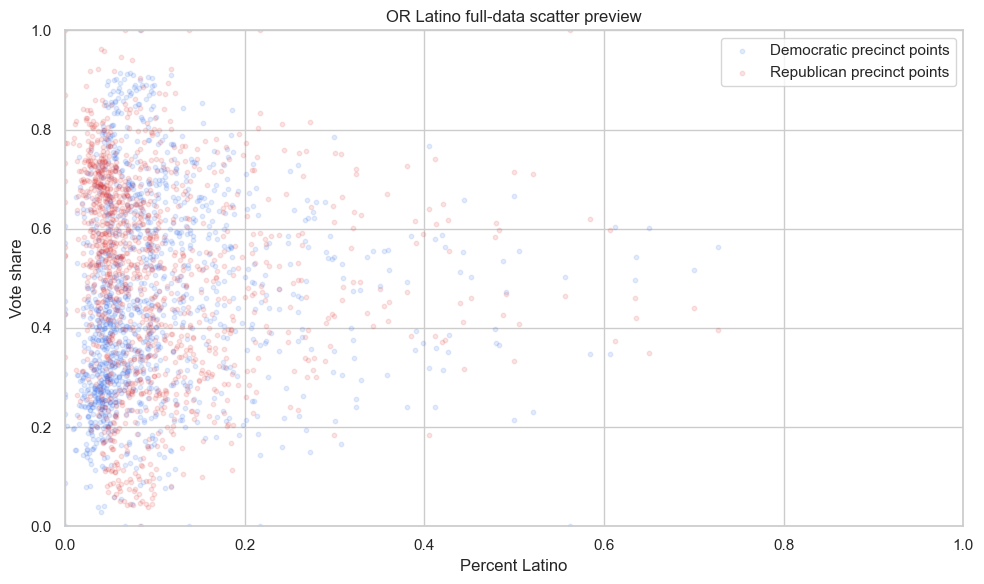

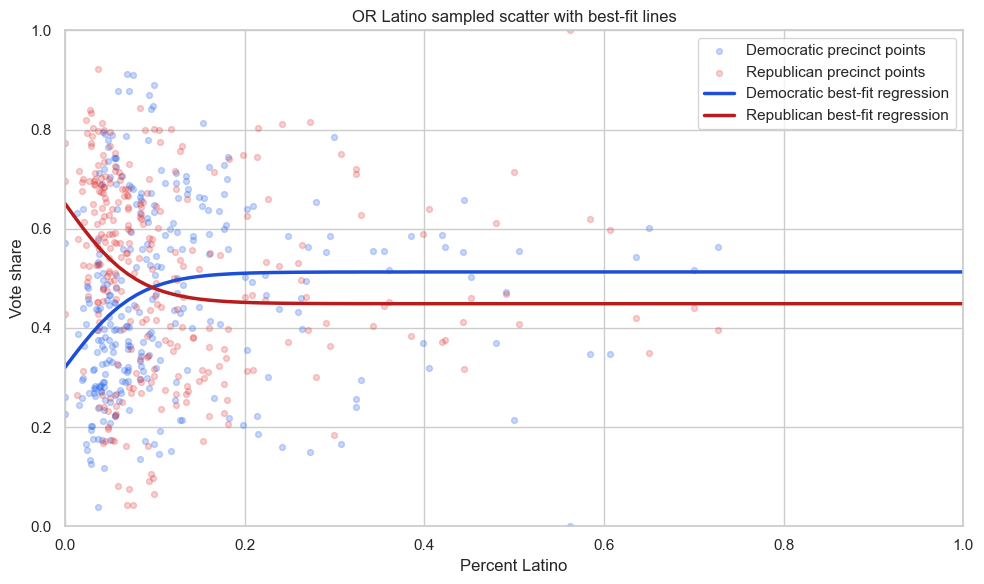

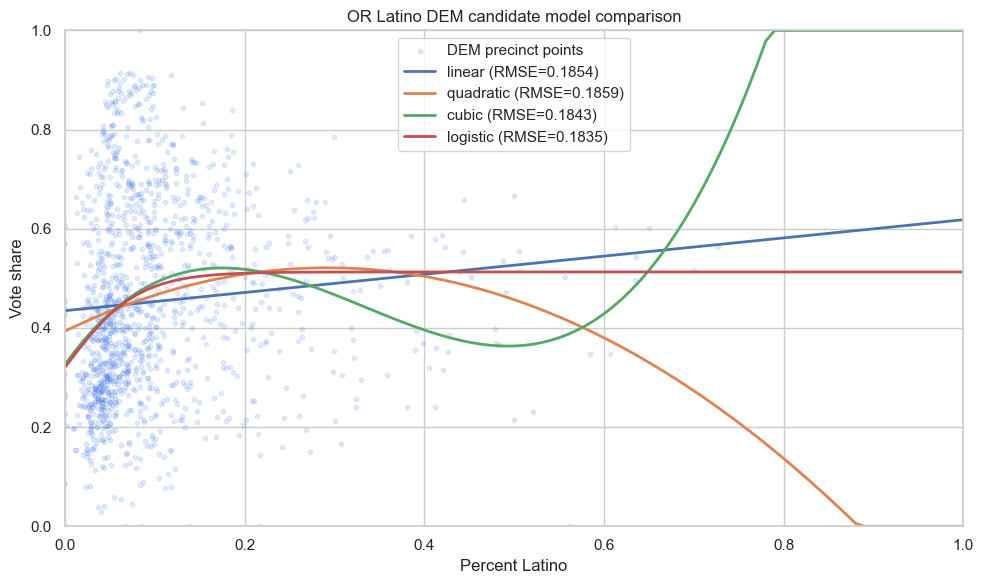

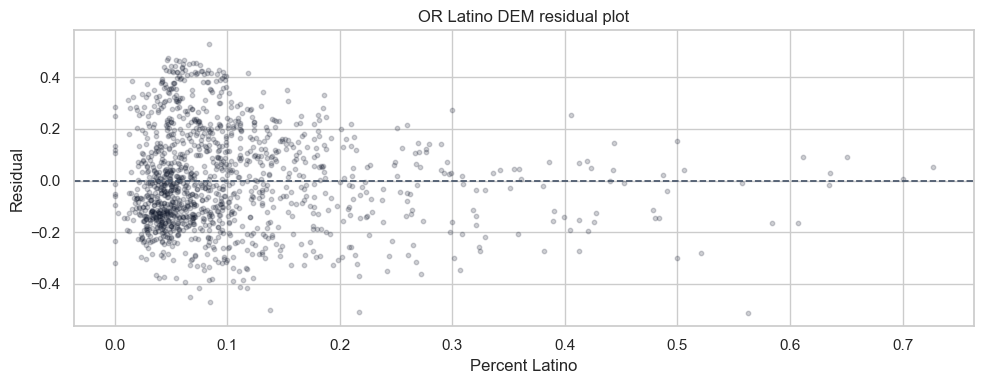

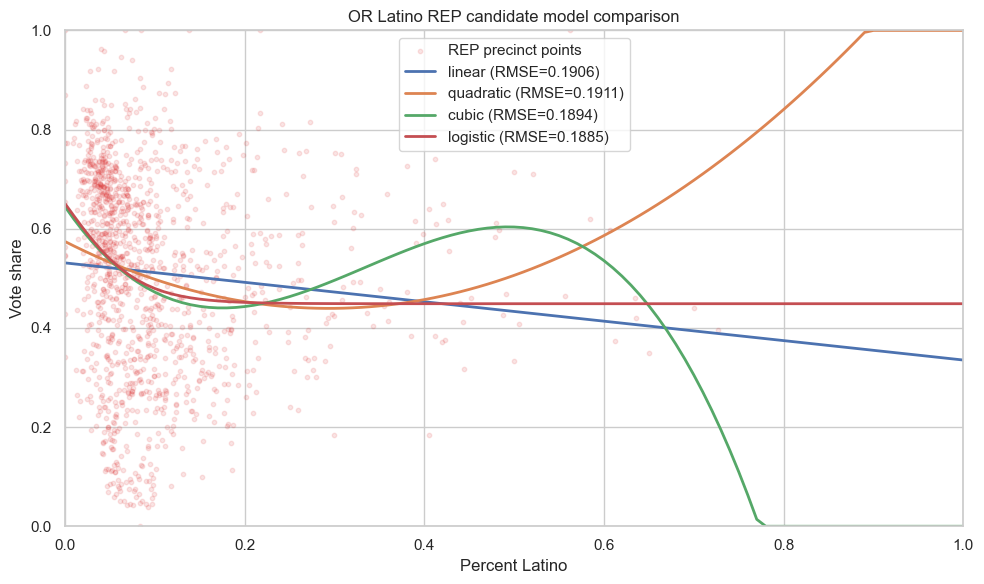

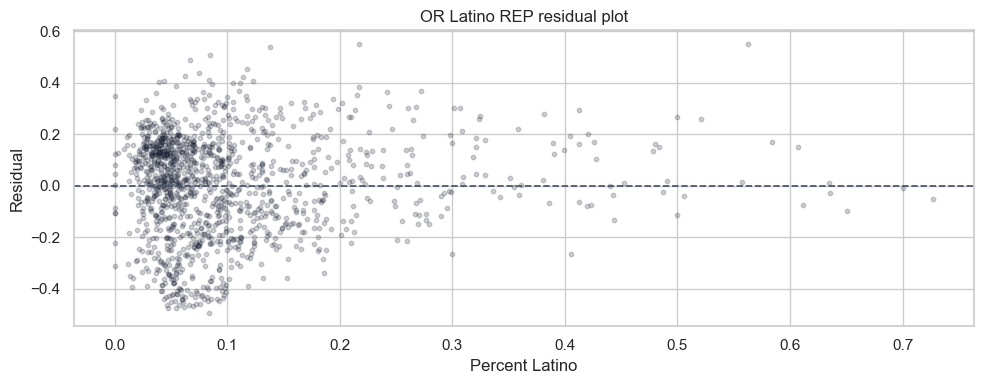

=== Final summary: OR Latino ===
Retained precinct count: 1,298
Excluded precinct count: 5
Best Democratic model form: logistic
Best Republican model form: logistic
Scatter output path: /Users/sahilparikh/Documents/CSE 416 Braves/preprocessing/output/OR_2024_latino_gingles_scatter.json
Table output path: /Users/sahilparikh/Documents/CSE 416 Braves/preprocessing/output/OR_2024_latino_gingles_table.json
Target DB collections: gingles_results, gingles_tables

##### Running pipeline for SC #####
--- SC source file input summary ---
Rows: 2,308
Null counts:
precinct_id         0
total               0
white               0
black               0
asian               0
hispanic            0
other               0
democratic_votes    0
republican_votes    0
total_votes         0
dtype: int64
Basic totals:
total               4014460
white               2603975
black                964667
asian                 70272
hispanic             231124
other                144422
democratic_votes    102583

,precinct_id,total,white,black,asian,hispanic,other,democratic_votes,republican_votes,total_votes,district,representative,party,incumbent_race,margin
0,0,1890,1361,439,7,31,52,354,923,1292,3,Jeff Duncan,Republican,White,0.68
1,1,1617,561,997,4,15,40,554,341,907,3,Jeff Duncan,Republican,White,0.68
2,2,1738,981,676,2,11,68,375,515,899,3,Jeff Duncan,Republican,White,0.68


--- Preprocessing-7 summary: SC Black ---
Input rows: 2,308
Retained rows: 2,308
Excluded rows: 0
Displayed sampled precincts: 400
Mean minority share: 0.2624
Mean Democratic vote share: 0.4254
Mean Republican vote share: 0.5604


,precinctId,precinctName,totalPopulation,minorityPopulation,minorityShare,democraticVotes,republicanVotes,totalVotes,demVoteShare,repVoteShare,winningParty,district,representative,party,incumbent_race,margin
0,0,0,1890,439,0.232275,354,923,1292,0.273994,0.714396,REP,3,Jeff Duncan,Republican,White,0.68
1,1,1,1617,997,0.616574,554,341,907,0.610805,0.375965,DEM,3,Jeff Duncan,Republican,White,0.68
2,2,2,1738,676,0.388953,375,515,899,0.417130,0.572859,REP,3,Jeff Duncan,Republican,White,0.68
3,3,3,925,284,0.307027,191,416,615,0.310569,0.676423,REP,3,Jeff Duncan,Republican,White,0.68
4,4,4,1391,140,0.100647,162,831,1004,0.161355,0.827689,REP,3,Jeff Duncan,Republican,White,0.68


SC fit context:
- Black share spans much more of the x-axis than Oregon Hispanic share.
- The fitted curve is typically smoother and more visually stable.
- Downsampling can be denser without losing the overall shape.
- Minority share range: 0.0000 to 0.9678
- Precincts at or above 50% minority share: 16.77%
- Selected models: DEM=cubic, REP=cubic
--- Preprocessing-8 summary: SC Black ---
Retained precinct count: 2,308
Displayed sampled precinct count: 400
DEM: model=cubic, RMSE=0.1113, R²=0.6489
REP: model=cubic, RMSE=0.1147, R²=0.6369


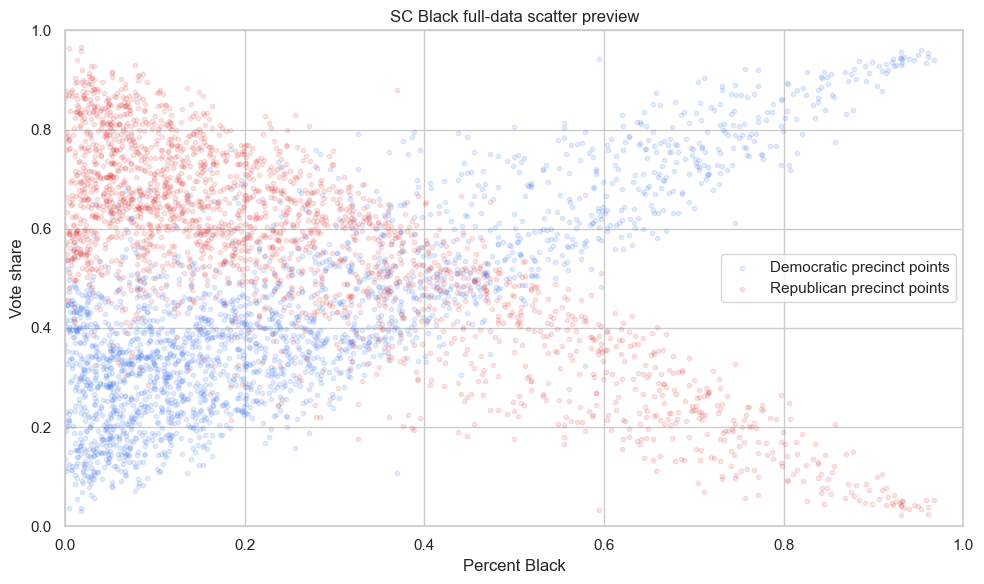

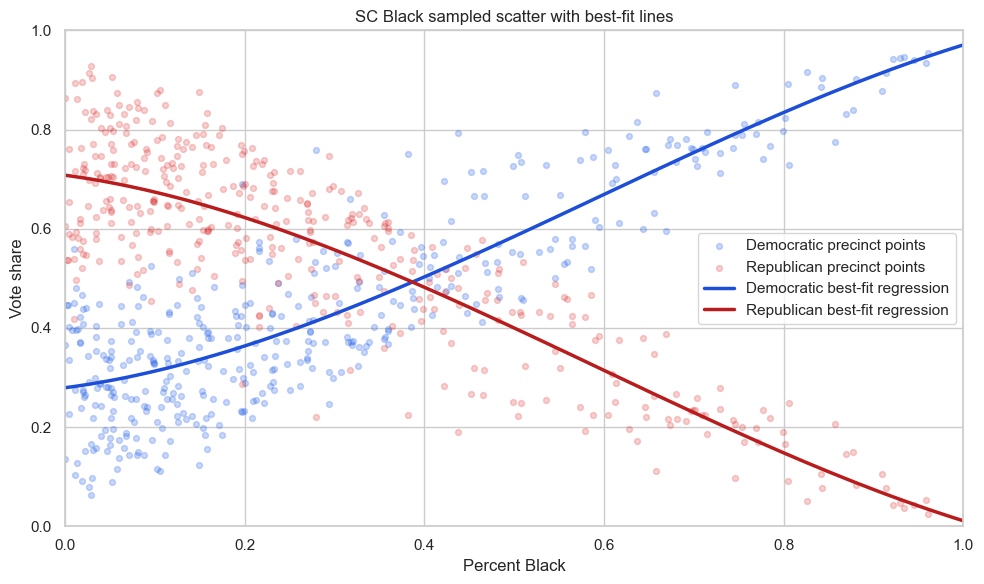

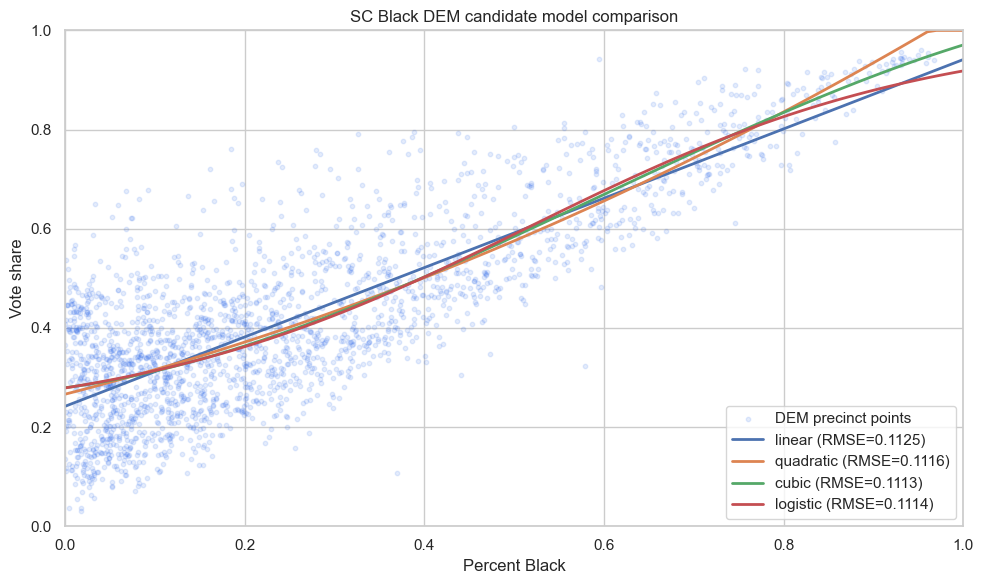

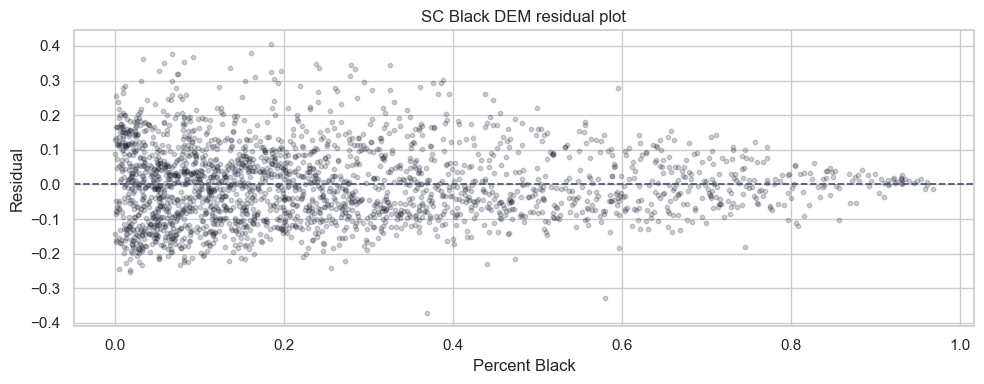

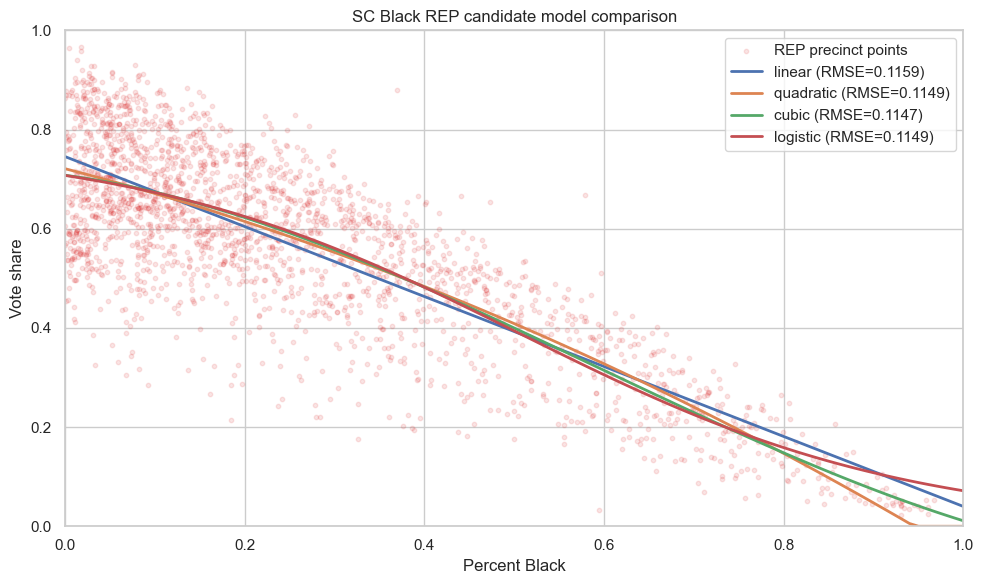

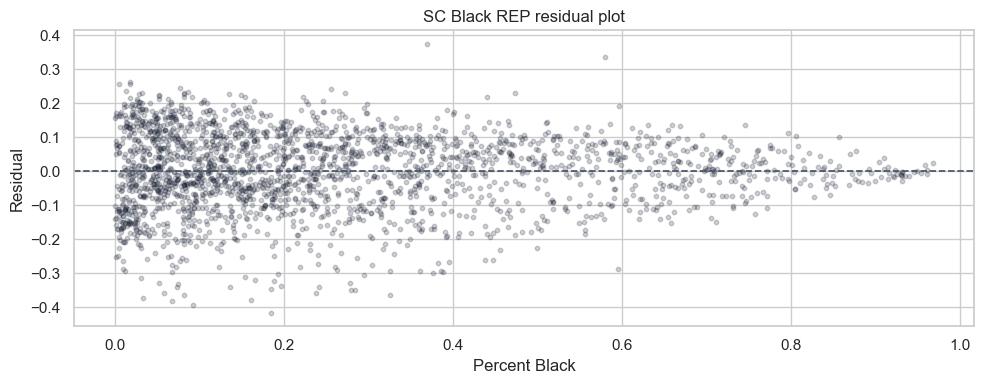

=== Final summary: SC Black ===
Retained precinct count: 2,308
Excluded precinct count: 0
Best Democratic model form: cubic
Best Republican model form: cubic
Scatter output path: /Users/sahilparikh/Documents/CSE 416 Braves/preprocessing/output/SC_2024_black_gingles_scatter.json
Table output path: /Users/sahilparikh/Documents/CSE 416 Braves/preprocessing/output/SC_2024_black_gingles_table.json
Target DB collections: gingles_results, gingles_tables


In [6]:
results = run_all_states(STATE_CONFIGS)
